# K-means clustering

In [1]:
# Fixes Windows-specific warning: "Could not find the number of physical cores"
# Manually sets joblib/scikit-learn to use our CPU's 6 physical cores,
# bypassing the broken Windows command-line lookup
import os
os.environ["LOKY_MAX_CPU_COUNT"] = "6"

In [2]:
import seaborn as sns
from sklearn.datasets import make_blobs

In [3]:
X, y = make_blobs(
    n_samples=1000,
    n_features=2,
    centers=4,
    random_state=42
)



<Axes: >

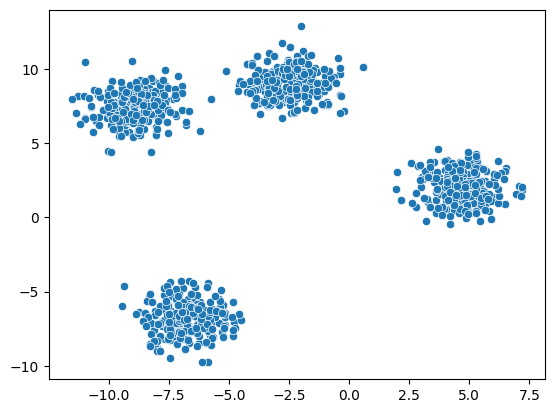

In [4]:
sns.scatterplot(x=X[:, 0], y=X[:, 1])



Feature scaling is essential for any algorithm that relies on distance calculations, gradient descent optimization, or variance maximization

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler() 

X_scaled = scaler.fit_transform(X)

In [6]:
from sklearn.cluster import KMeans

K = 4

kmeans = KMeans(
    n_clusters=K,
    n_init=10,
    random_state=42
)

labels = kmeans.fit_predict(X)

<Axes: >

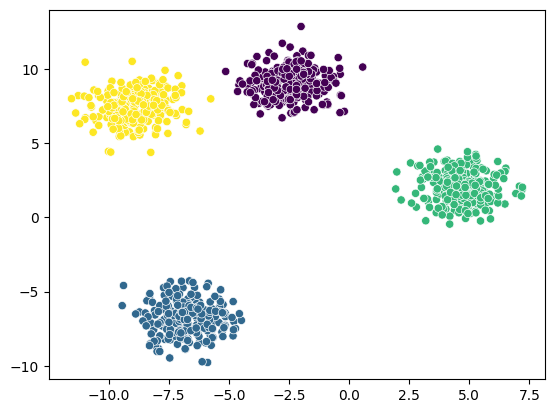

In [7]:
sns.scatterplot(x=X[:, 0], y=X[:, 1], c=labels)

## choose k value, elbow; silhouette score

### Elbow method

In [8]:
wcss = [] 
for k in range(1, 21):
    kmeans = KMeans(n_clusters=k, n_init=10) 
    kmeans.fit_predict(X) 
    wcss.append(kmeans.inertia_)

<Axes: >

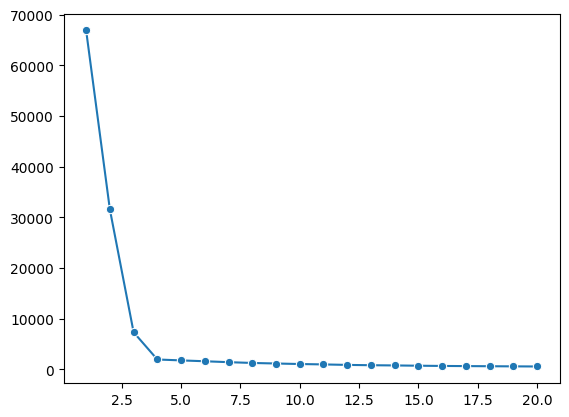

In [9]:
sns.lineplot(x=range(1, 21), y=wcss, marker='o')

%pip install kneed

In [10]:
from kneed import KneeLocator

In [11]:
knee = KneeLocator(range(1, 21), wcss, curve="convex", direction="decreasing") 
print("optimal K: ", knee.elbow)

optimal K:  4


### Silhouette Score

In [12]:
from sklearn.metrics import silhouette_score

ss = [] 

for k in range(2, 21):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X) 
    score = silhouette_score(X, labels)
    
    ss.append(score)

<Axes: >

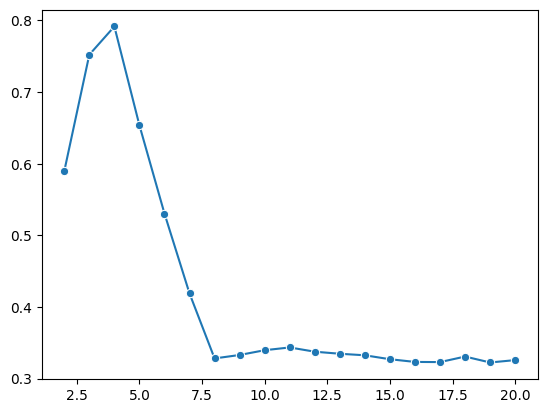

In [13]:
sns.lineplot(x=range(2, 21), y=ss, marker="o")

In [14]:
best_k = range(2, 21)[ss.index(max(ss))]

print("Best K from Silhouette:", best_k)
print("Best Silhouette Score:", max(ss))

Best K from Silhouette: 4
Best Silhouette Score: 0.7915983870089952
